In [1]:
import pickle
from cmdstanpy import CmdStanModel
import arviz as az

In [ ]:
model = CmdStanModel(stan_file='goncalves1.stan')
fit = model.sample(data='goncalves.data.json', inits='goncalves.init.json', show_console=False, show_progress=True, chains=4, parallel_chains=4,
                   iter_warmup=1000, iter_sampling=1000)

draws = fit.draws_pd()
draws.to_csv('goncalves1_draws.csv')
with open('goncalves1_fit.pickle', 'wb') as f:
    pickle.dump(fit, f)

16:39:12 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

16:46:32 - cmdstanpy - INFO - CmdStan done processing.
16:46:32 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: multinomial_lpmf: Probabilities parameter is not a valid simplex. sum(Probabilities parameter) = -nan, but should be 1 (in 'goncalves1.stan', line 288, column 4 to column 38)
	Exception: multinomial_lpmf: Probabilities parameter is not a valid simplex. sum(Probabilities parameter) = -nan, but should be 1 (in 'goncalves1.stan', line 288, column 4 to column 38)
	Exception: multinomial_lpmf: Probabilities parameter is not a valid simplex. sum(Probabilities parameter) = -nan, but should be 1 (in 'goncalves1.stan', line 288, column 4 to column 38)
	Exception: binomial_lpmf: Probability parameter[1] is inf, but must be in the interval [0, 1] (in 'goncalves1.stan', line 289, column 4 to column 59)
	Exception: binomial_lpmf: Probability parameter[1] is inf, but must be in the interval [0, 1] (in 'goncalves1.stan', line 289, column 4 to column 59)
	Exception: binom

In [3]:
with open('goncalves1_fit.pickle', 'rb') as f:
    fit = pickle.load(f)
# print(fit.diagnose())

Rhat values good

In [4]:
vars = ['lambda', 's', 'aF', 'cF', 'aS', 'cS', 'bS', 'dS']

print(az.rhat(fit, var_names=vars))

<xarray.Dataset> Size: 64B
Dimensions:  ()
Data variables:
    lambda   float64 8B 1.0
    s        float64 8B 1.002
    aF       float64 8B 1.0
    cF       float64 8B 0.9997
    aS       float64 8B 1.0
    cS       float64 8B 1.001
    bS       float64 8B 1.001
    dS       float64 8B 1.001


Effective samples sizes good

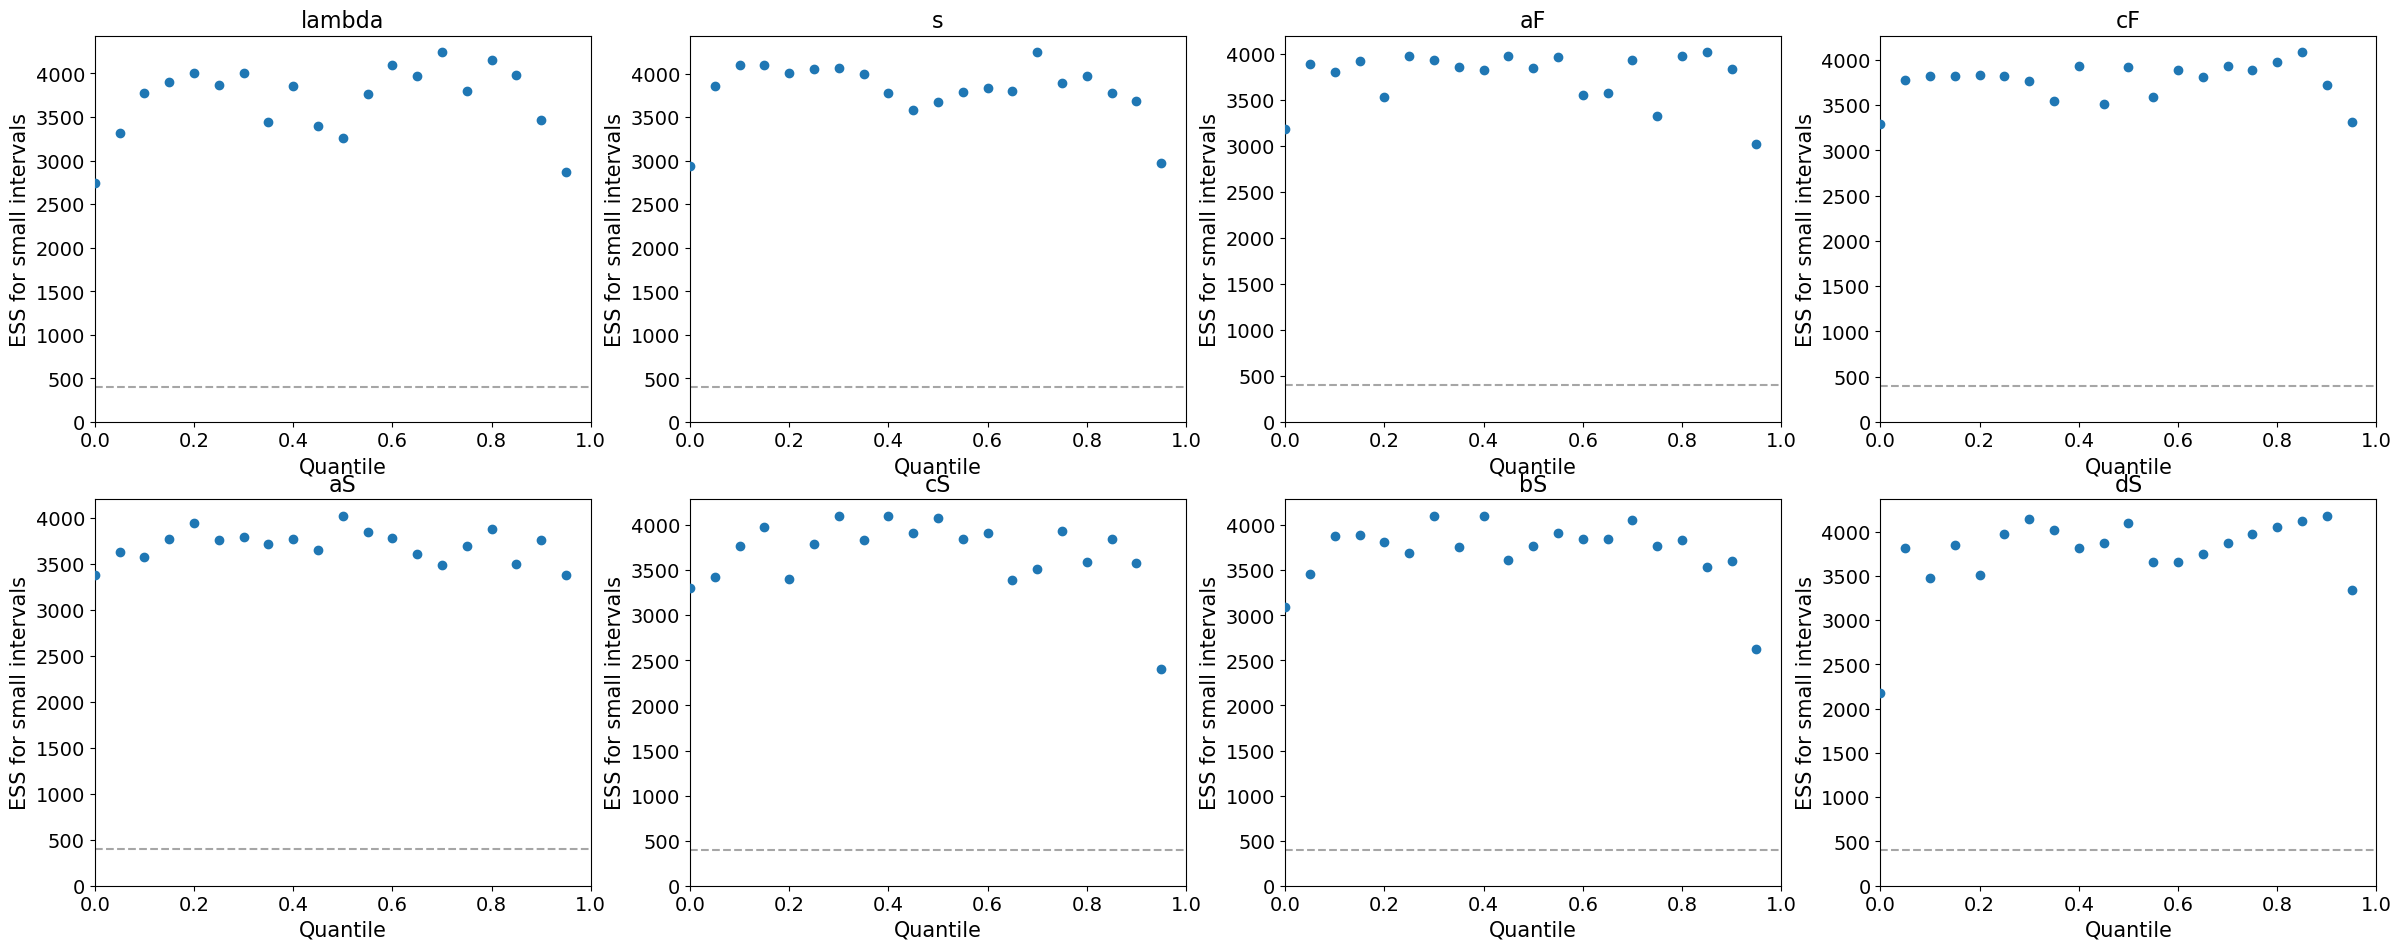

In [5]:
az.plot_ess(fit, var_names=vars);

No autocorrelation

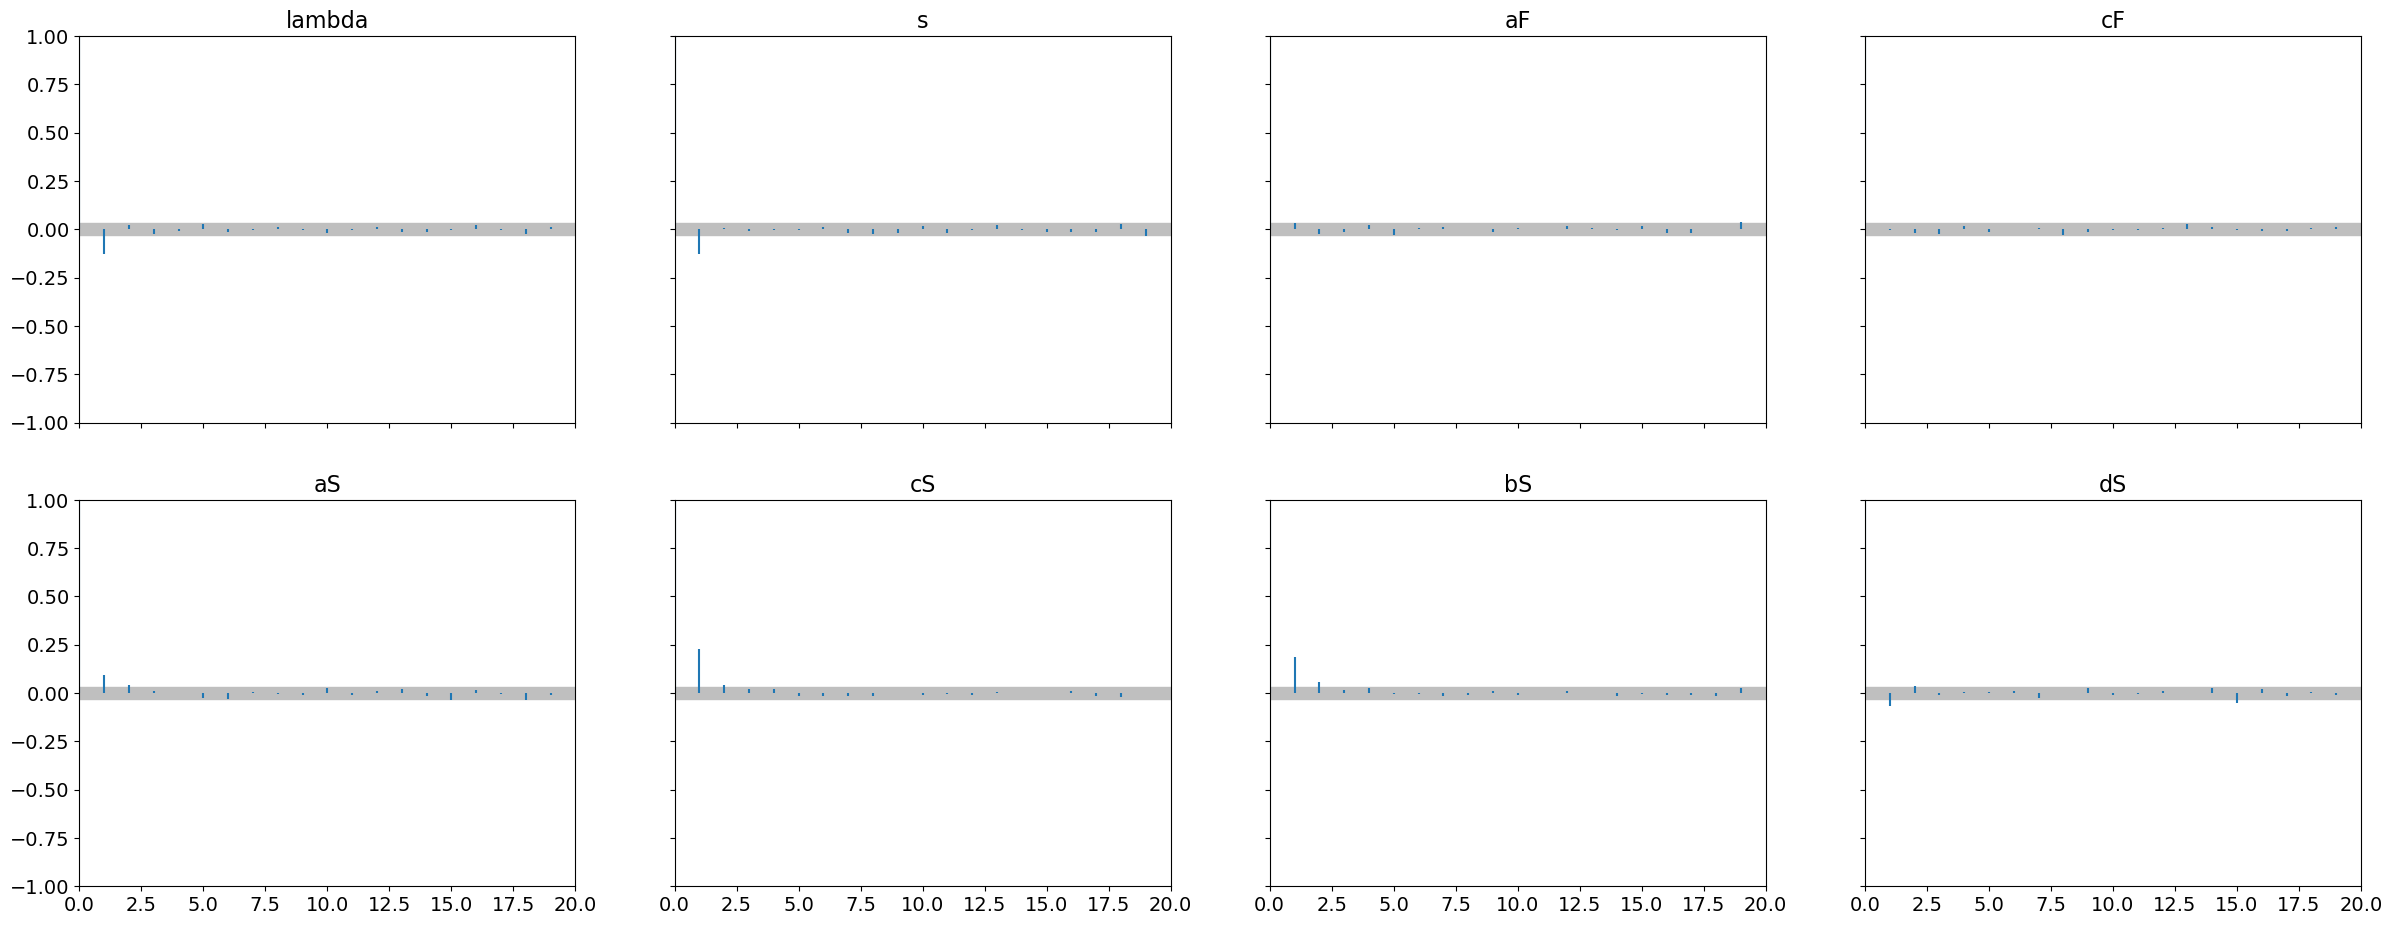

In [6]:
az.plot_autocorr(fit, var_names=vars, combined=True, max_lag=20,);

Chains look good

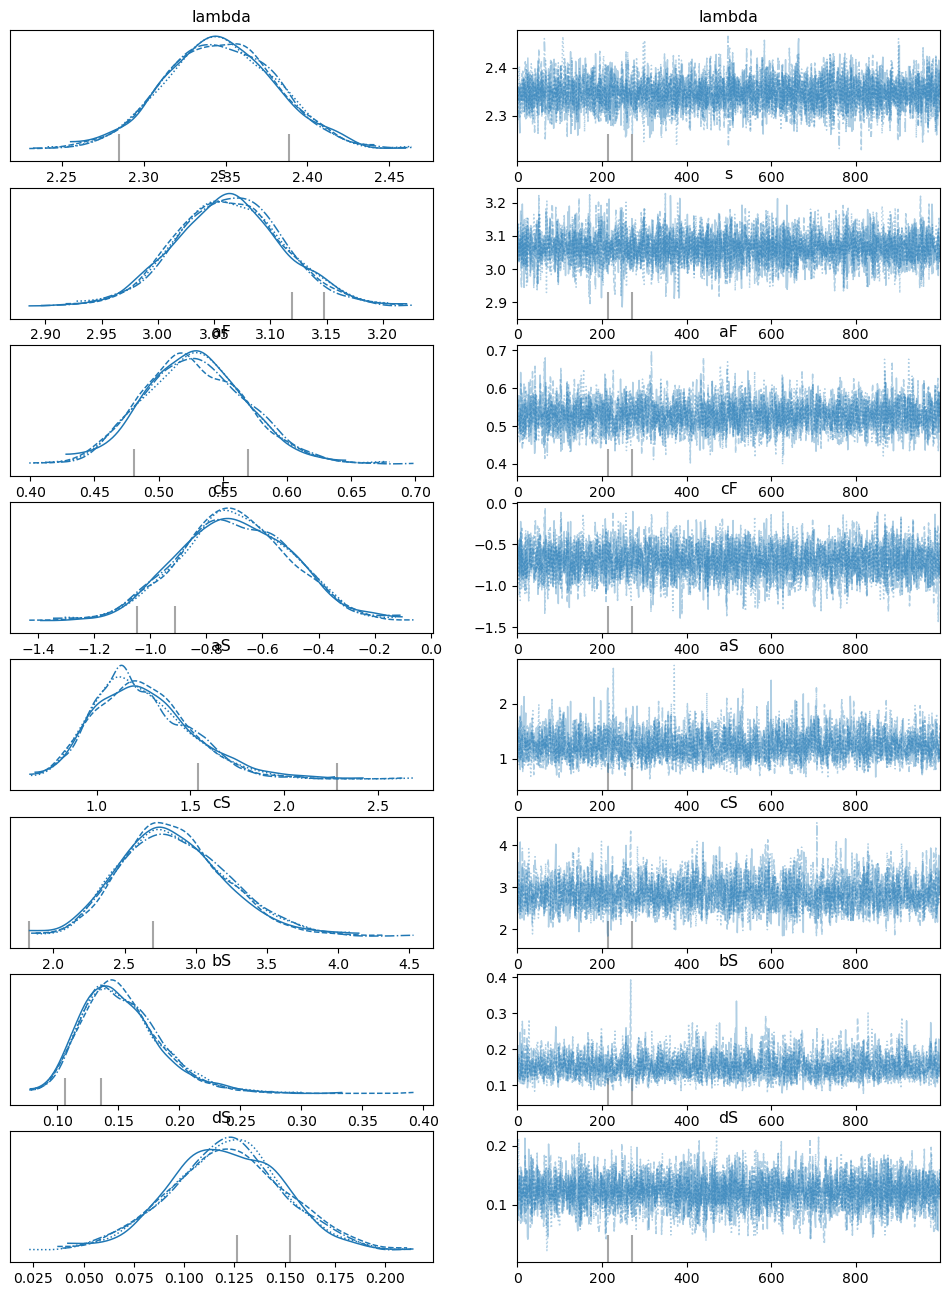

In [7]:
az.plot_trace(fit, var_names=vars);

No major identifiability issues

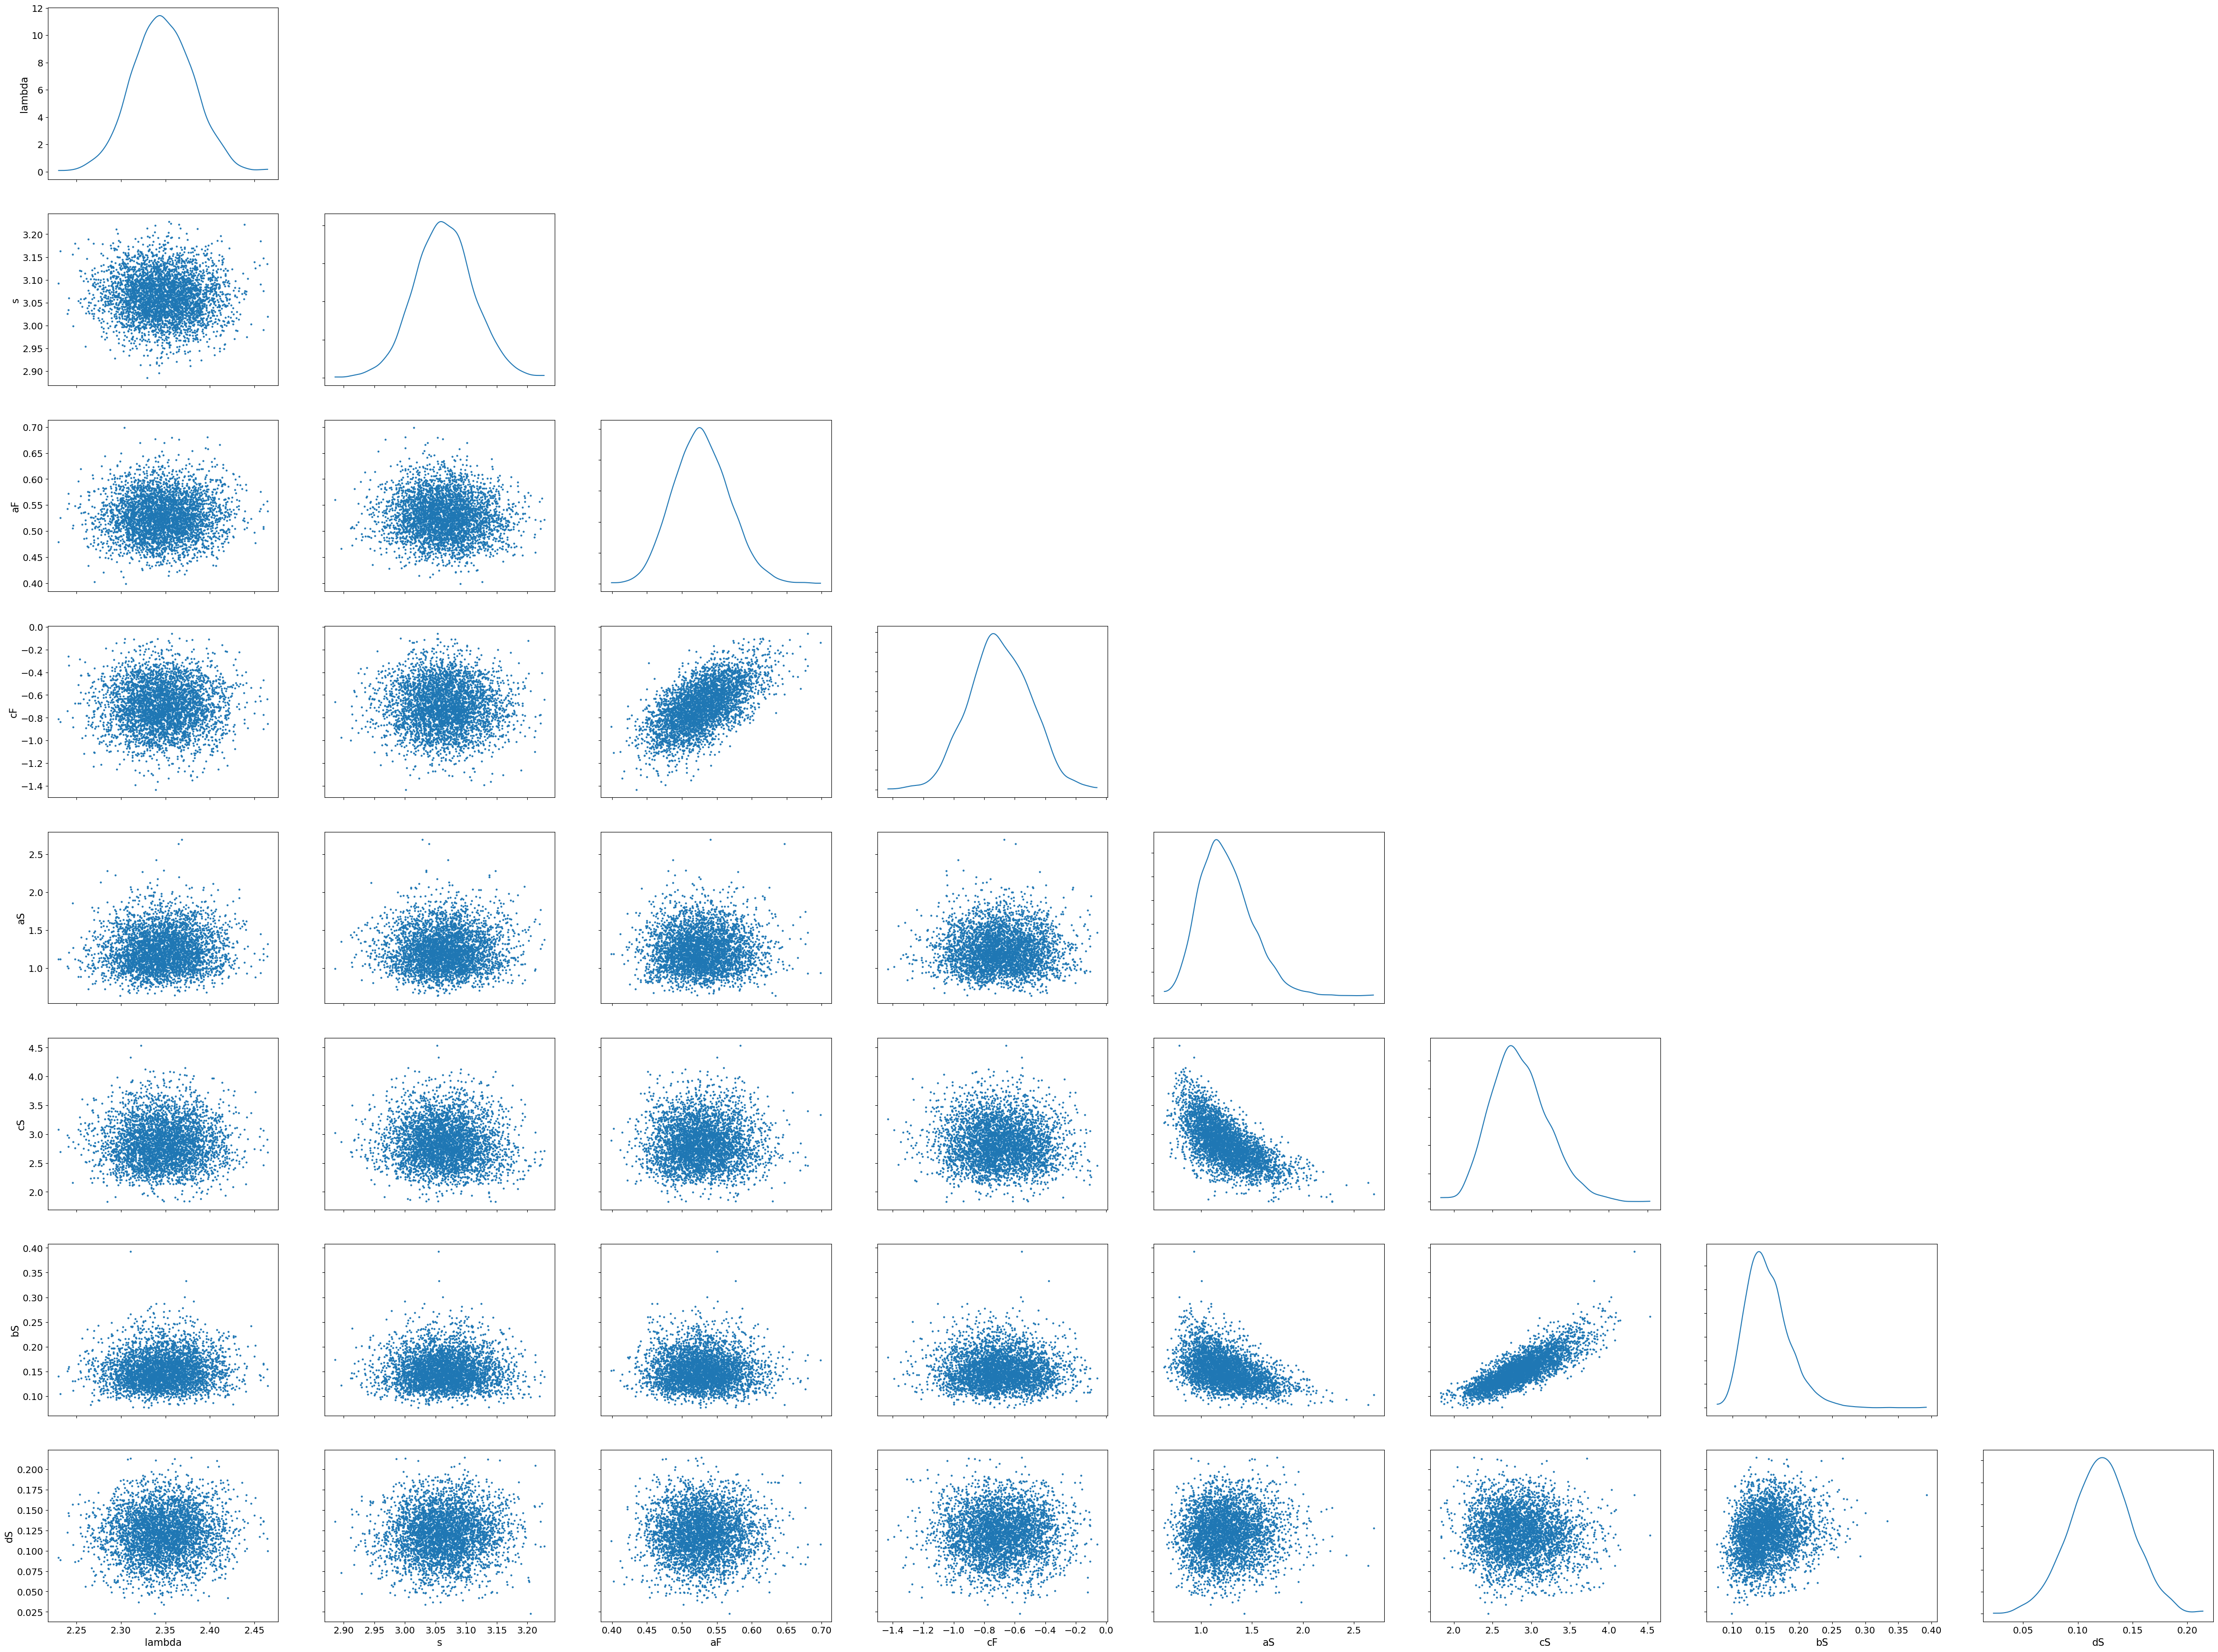

In [8]:
az.plot_pair(fit, var_names=vars, marginals=True);